In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

In [2]:
def calculate_alpha(u, v):
    # Define the structural overlap integral K(alpha)
    def K(alpha):
        integrand = lambda x: (x**alpha * (1 - x)**alpha) / (x**alpha + (1 - x)**alpha)
        result, _ = quad(integrand, 0, 1, limit=100)
        return result

    # Define the characteristic equation: f(alpha) = 0
    def characteristic_eq(alpha):
        return (2 * (u + v) / (alpha + 1)) - v * K(alpha) - 1


    sol = root_scalar(characteristic_eq, bracket=[2*u+v-1, 2*(u + v) - 1], method='brentq')
    print(f"Root found: {sol.root}, f(root) = {characteristic_eq(sol.root)}")

    return sol.root


In [3]:
u=0.5
v=0.3
alpha = calculate_alpha(u, v)
alpha

Root found: 0.4676351367596706, f(root) = -2.220446049250313e-16


0.4676351367596706

In [ ]:
def compute_zns(N, u, v, lambdas):
    """
    Computes the expected sequence z_n exactly up to N using dynamic programming.
    """
    z = np.zeros(N + 1)
    
    # Base cases for Y_0 = 0 and Y_1 = 0
    z[0] = 1.0  
    z[1] = 0.0  
    
    for n in range(1, N):

        sum_prod = 0.0
        sum_max = 0.0
        
        for i in range(n):
            
            beta_i = np.log(lambdas[n + 1]) / np.log(lambdas[i])
            beta_n1_i = np.log(lambdas[n + 1]) / np.log(lambdas[n - 1 - i])
            
            # Compute the fractional powers
            z_i_pow = z[i]**beta_i
            z_comp_pow = z[n - 1 - i]**beta_n1_i
            
            sum_prod += z_i_pow * z_comp_pow
            sum_max += np.maximum(z[i],  z[n - 1 - i])
            
        z[n + 1] = (lambdas[n + 1] * u / n) * sum_prod + (v / n) * sum_max + 1.0 - u - v

        if  n % 1000 == 0:
            print(f"Iteration {n}")
        
    return z

Iteration 1000
Iteration 2000
Iteration 3000
Iteration 4000


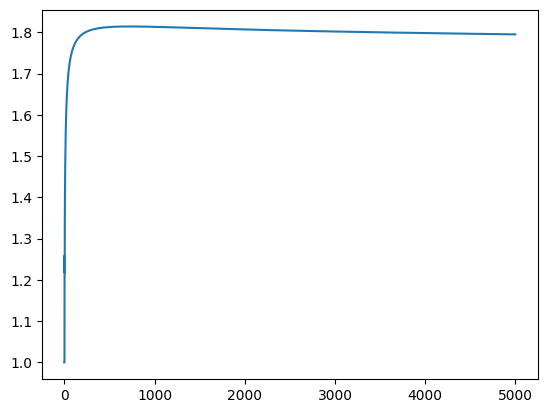

In [17]:
N_target = 5000
u = 0.5
v = 0.3
lambdas = [1.0 + 1/((i+1)**0.6) for i in range(N_target + 1)]

zns = compute_zns(N_target, u, v, lambdas)

plt.plot(range(N_target + 1), zns)
plt.show()

In [12]:
def compute_zns(N, u, v, lambdas):
    """
    Computes the expected sequence z_n exactly up to N using dynamic programming.
    """
    z = np.zeros(N + 1)
    
    # Base cases for Y_0 = 0 and Y_1 = 0
    z[0] = 1.0  
    z[1] = 1.0  
    
    for n in range(1, N):

        sum_prod = 0.0
        sum_sum = 0.0
        
        for i in range(n):
            
            beta_i = np.log(lambdas[n + 1]) / np.log(lambdas[i])
            beta_n1_i = np.log(lambdas[n + 1]) / np.log(lambdas[n - 1 - i])
            
            # Compute the fractional powers
            z_i_pow = z[i]**beta_i
            z_comp_pow = z[n - 1 - i]**beta_n1_i
            
            sum_prod += z_i_pow * z_comp_pow
            sum_sum += z_i_pow + z_comp_pow
            
        z[n + 1] = (lambdas[n + 1] * u / n) * sum_prod + (v / n) * sum_sum + 1.0 - u - 2.0*v

        if  n % 1000 == 0:
            print(f"Iteration {n}")
        
    return z

Iteration 1000
Iteration 2000
Iteration 3000
Iteration 4000


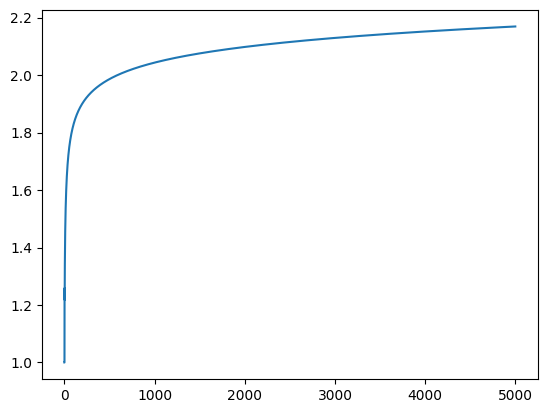

In [15]:
N_target = 5000
u = 0.5
v = 0.3
lambdas = [1.0 + 1/((i+1)**0.6) for i in range(N_target + 1)]

zns = compute_zns(N_target, u, v, lambdas)

plt.plot(range(N_target + 1), zns)
plt.show()